best to run on jupyterhub with gpu

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [2]:
from types import SimpleNamespace

with open("/mnt/home/hqu10/ml-4m/cfgs/default/tokenization/vqvae/rgb/mi_rgb2.yaml", "r") as f:
    args = yaml.safe_load(f)
args['full_ckpt'] = None
args['encoder_ckpt'] = None
args['mask_value'] = args.get('mask_value', None)
args['input_size_enc'] = args.get('input_size_enc', None)
args['input_size_dec'] = args.get('input_size_dec', None)
args['num_codebooks'] = 1
args['norm_latents'] = False
args['distributed'] = False
# args['quantizer_ema_decay'] = args.get('quantizer_ema_decay', 0.8)
args['code_replacement_policy'] = args.get('code_replacement_policy', 'batch_random')
# args['kmeans_init'] = False
args['freeze_enc'] = False
args['out_conv'] = False

args = SimpleNamespace(**args)

In [3]:
from fourm.vq.vqvae import VQVAE
from fourm.data.mi_dataset import MIDataset
from fourm.data.dataset_utils import split_mi_data_paths
from run_training_vqvae import get_model

/mnt/home/hqu10/.venv/fourm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/home/hqu10/.venv/fourm/lib/python3.10/site-packages/setuptools/version.py:1: UserWarning: Module fourm was already imported from None, but /mnt/home/hqu10/ml-4m is being added to sys.path
  import pkg_resources
/mnt/home/hqu10/ml-4m/fourm/vq/quantizers/quantize_lucid.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/mnt/home/hqu10/ml-4m/fourm/vq/quantizers/quantize_lucid.py:388: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)


xFormers not available
xFormers not available
No module named 'detectron2'
Detectron2 can be used for semseg visualizations. Please install detectron2 to use this feature, or plotting will fall back to matplotlib.
No module named 'smplx'
Human pose dependencies are not installed, hence poses will not be visualized. To visualize them (optional), you can do the following: 
1) Install via `pip install timm yacs smplx pyrender pyopengl==3.1.4` 
   You may need to follow the pyrender install instructions: https://pyrender.readthedocs.io/en/latest/install/index.html 
2) Download SMPL data from https://smpl.is.tue.mpg.de/. See https://github.com/shubham-goel/4D-Humans/ for an example. 
3) Copy the required SMPL files (smpl_mean_params.npz, SMPL_to_J19.pkl, smpl/SMPL_NEUTRAL.pkl) to fourm/utils/hmr2_utils/data .
No module named 'fourm.utils.imagebind'
ImageBind utils are not found, if you'd like to train an ImageBind tokenizer, please install them following the official instructions at https:/

In [4]:
model = get_model(args, "cuda")
ckpt = torch.load("/mnt/ceph/users/hqu10/mi_outputs/rgb2_tokenizer_case1/checkpoint-final.pth", weights_only=False)
model.load_state_dict(ckpt['model'])

Computed dead code EMA threshold: 0.2500


<All keys matched successfully>

In [5]:
ckpt.keys()

dict_keys(['model', 'epoch', 'args', 'scaler', 'optimizer', 'model_ema'])

In [5]:
parent_data_dir = Path("/mnt/home/hqu10/ceph/mi_datasets")
# data_dir = parent_data_dir / Path(ckpt['args'].data_path).name
_, _, test_paths = split_mi_data_paths(ckpt['args'].data_path)
print(test_paths)
dataset = MIDataset(test_paths)

[PosixPath('/mnt/ceph/users/hqu10/mi_datasets/Case_1/Case1_9.npz')]


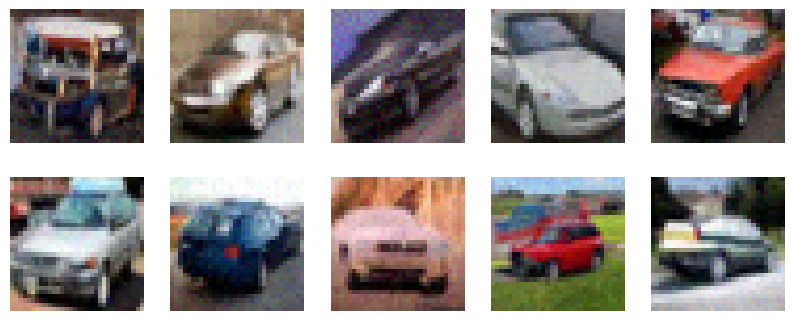

In [29]:
rand_idxs = np.random.randint(0, 100_001, size=10)
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
for i in range(10):
    ax = axs[i % 2, i // 2]
    ax.imshow(dataset[i]['rgb1'].transpose(1, 2, 0))
    ax.axis('off')

In [6]:
rand_idxs = np.random.randint(0, len(dataset)+1, size=32)
batch = torch.tensor(dataset[rand_idxs]['rgb2'])
print(batch.shape)
batch = batch.to('cuda')

torch.Size([32, 3, 32, 32])


In [7]:
embed, loss, _ = model.encode(batch)

/mnt/home/hqu10/ml-4m/fourm/vq/models/vit_models.py:495: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled = False):


In [8]:
embed.shape

torch.Size([32, 32, 8, 8])

In [66]:
preds, loss = model(batch)

/mnt/home/hqu10/ml-4m/fourm/vq/models/vit_models.py:495: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled = False):


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.13283253..1.0403397].


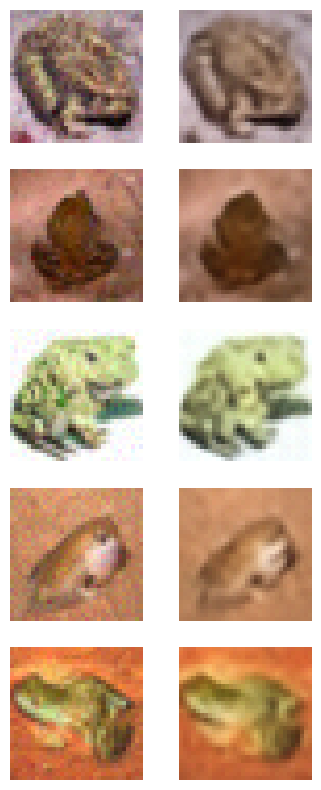

In [67]:
fig, axs = plt.subplots(5, 2, figsize=(4, 10))
for i in range(5):
    axs[i % 5, 0].imshow(batch[i].cpu().permute(1, 2, 0))
    axs[i % 5, 0].axis('off')
    axs[i % 5, 1].imshow(preds[i].detach().cpu().permute(1, 2, 0))
    axs[i % 5, 1].axis('off')

In [17]:
print(np.max(dataset[:100]['theta']), np.min(dataset[:100]['theta']))

185.77551 -212.81989


In [11]:
import torchvision

In [12]:
a = torchvision.models.resnet18()
a

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
sum(p.numel() for p in a.parameters() if p.requires_grad)

11689512

In [14]:
cifar10_trained = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
cifar10_trained

/mnt/home/hqu10/.venv/fourm/lib/python3.10/site-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /mnt/home/hqu10/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /mnt/home/hqu10/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt
100%|█████████

CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

# extract embeddings from trained model

In [1]:
import torch
from run_training_4m import setup_data, get_model

device = 'cuda' if torch.cuda.is_available() else 'cpu'

/mnt/home/hqu10/.venv/fourm/lib/python3.10/site-packages/setuptools/version.py:1: UserWarning: Module fourm was already imported from None, but /mnt/home/hqu10/ml-4m is being added to sys.path
  import pkg_resources
/mnt/home/hqu10/.venv/fourm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Loading checkpoint
checkpoint = torch.load('/mnt/ceph/users/hqu10/mi-4m/mi_outputs/4m/models/main/helen_test/checkpoint-16.pth', weights_only=False)

In [4]:
## Associated data
modality_info, data_loader_train, num_training_steps_per_epoch, data_loaders_val, data_loaders_fixed_eval = setup_data(checkpoint['args'])

## Recreating the model
model = get_model(checkpoint['args'], modality_info).eval().to(device)

# Loading the model
model.load_state_dict(checkpoint['model'])

Loading data config from: cfgs/default/4m/data/helen_test.yaml
modality_info: {'tok_rgb1@32': {'input_size': 32, 'patch_size': 4, 'vocab_size': 16384, 'encoder_embedding': functools.partial(<class 'fourm.models.encoder_embeddings.ImageTokenEncoderEmbedding'>, vocab_size=16384), 'decoder_embedding': functools.partial(<class 'fourm.models.decoder_embeddings.ImageTokenDecoderEmbedding'>, vocab_size=16384), 'min_tokens': 0, 'max_tokens': 64, 'type': 'img', 'id': 10990, 'pretokenized': True}, 'tok_rgb2@32': {'input_size': 32, 'patch_size': 4, 'vocab_size': 16384, 'encoder_embedding': functools.partial(<class 'fourm.models.encoder_embeddings.ImageTokenEncoderEmbedding'>, vocab_size=16384), 'decoder_embedding': functools.partial(<class 'fourm.models.decoder_embeddings.ImageTokenDecoderEmbedding'>, vocab_size=16384), 'min_tokens': 0, 'max_tokens': 64, 'type': 'img', 'id': 28392, 'pretokenized': True}}
Setting up dataset helen_test / train
Loading alphas config from: cfgs/default/4m/alphas_mixt

<All keys matched successfully>

In [6]:
def get_embeddings(self, mod_dict): # from https://github.com/PolymathicAI/4Mclone/blob/main/notebooks/gaia/stellar_parameters.ipynb
    """
    Forward pass for the model.

    Args:
        mod_dict (Dict[str, Dict[str, torch.Tensor]]): Dictionary containing the tensors, masks, and other info for each modality.
            - mod_dict[modality_name]["tensor_name"]: Shape can vary based on tensor_name and modality.

    Returns:
        Union[dict, tuple]: 
            - If return_logits is True: Dictionary of logits for each modality.
            - Otherwise: Tuple containing the total loss and dictionary of loss for each modality.
    """

    # Mod dicts
    encoder_mod_dict = {mod: self.encoder_embeddings[mod](d)
                        for mod, d in mod_dict.items()
                        if mod in self.encoder_embeddings}
    encoder_tokens, encoder_emb, encoder_mask, encoder_mod_mask = self.forward_mask_encoder(encoder_mod_dict, 128)

    # Encoder
    x = encoder_tokens + encoder_emb
    x = self.forward_encoder(x, encoder_mask=encoder_mask)

    # Mean pooling
    return x.mean(1)

In [8]:
next(iter(data_loader_train))

/mnt/home/hqu10/ml-4m/fourm/data/masking.py:196: FutureWarning: `sample_n(n)` will be deprecated. Use `sample((n,))` instead.
  input_token_budget += torch.bincount(self.input_dirichlets[dir_idx].sample_n(diff).argmax(dim=-1), minlength=len(input_token_budget))
/mnt/home/hqu10/ml-4m/fourm/data/masking.py:225: FutureWarning: `sample_n(n)` will be deprecated. Use `sample((n,))` instead.
  target_token_budget += torch.bincount(self.target_dirichlets[dir_idx].sample_n(diff).argmax(dim=-1), minlength=len(target_token_budget))
/mnt/home/hqu10/ml-4m/fourm/data/masking.py:196: FutureWarning: `sample_n(n)` will be deprecated. Use `sample((n,))` instead.
  input_token_budget += torch.bincount(self.input_dirichlets[dir_idx].sample_n(diff).argmax(dim=-1), minlength=len(input_token_budget))
/mnt/home/hqu10/ml-4m/fourm/data/masking.py:225: FutureWarning: `sample_n(n)` will be deprecated. Use `sample((n,))` instead.
  target_token_budget += torch.bincount(self.target_dirichlets[dir_idx].sample_n(diff

{'tok_rgb1@32': {'tensor': tensor([[ 749,  749,  749,  ...,  171,  392,  392],
          [ 546,  546,  749,  ..., 1020,  104, 1020],
          [ 104,  104,  104,  ...,  546,  104,  104],
          ...,
          [ 749,  546,  546,  ...,  605,  204,  325],
          [ 104,  104,  104,  ...,  104, 1020,  104],
          [ 104,  104,  104,  ...,  144,  910,  201]]),
  'input_mask': tensor([[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]]),
  'target_mask': tensor([[True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          ...,
          [True, True, True,  ..., True, True, True

In [10]:
from fourm.vq import get_image_tokenizer

tokenizer, _ = get_image_tokenizer(
    "rgb1_tokenizer_case2_rho0999/checkpoint-final", 
    tokenizers_root="/mnt/home/hqu10/ceph/mi-4m/mi_outputs/tokenization", 
    encoder_only=True
)

Loading tokenizer rgb1_tokenizer_case2_rho0999/checkpoint-final ... <All keys matched successfully>


In [19]:
import os
from fourm.data.mi_dataset import MIDataset
from fourm.data.modality_info import MODALITY_TRANSFORMS_DIVAE
from torch.utils.data import Dataset
from typing import Optional

class SaveVQDataset(Dataset):
    def __init__(self, 
                 root: str, 
                 tokens_dir: str, 
                 crop_settings_dir: str, 
                 task: str, 
                 n_crops: int = 10, 
                 min_crop_scale: float = 0.2,
                 input_size: int = 224, 
                 mask_value: Optional[float] = None,
                 task_transforms: dict = MODALITY_TRANSFORMS_DIVAE,
                 resample_mode: str = 'bilinear',
                 corrupt_samples_log: Optional[str] = None,
                 dryrun: bool = False,
                 force_load_crop: bool = False,
                 use_np_shards: bool = False):
        super().__init__()
        
        self.data_root = root
        self.tokens_root = os.path.join(root, tokens_dir)
        self.crop_settings_root = os.path.join(root, crop_settings_dir)
        self.n_crops = n_crops
        self.input_size = input_size
        self.task = task
        self.mask_value = mask_value
        self.task_transforms = task_transforms
        self.resample_mode = resample_mode

        self.force_load_crop = force_load_crop

        self.dryrun = dryrun
        self.force_load_crop = force_load_crop
        
        self.use_np_shards = use_np_shards
        
        if self.use_np_shards:
            data_paths = list(Path(root).glob('*.npz'))
            self.samples = MIDataset(data_paths)
        else:
            raise ValueError("this class was designed for np shards datasets")
        
        self.center_crop_augmenter = CenterCropImageAugmenter(
            target_size=self.input_size, hflip=0.0, main_domain=task
        )
        self.random_crop_augmenter = RandomCropImageAugmenter(
            target_size=self.input_size, hflip=0.5, 
            crop_scale=(min_crop_scale, 1.0),
            crop_ratio=(0.75, 1.3333),
            main_domain=task
        )
    
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        raw = sample[self.task]
        raw = (raw * 255).astype(np.uint8).transpose(1, 2, 0)
        img = Image.fromarray(raw)

        theta = sample['theta']

        tokens_path = str(Path(self.tokens_root) / sample['id'])
        crop_settings_path = str(Path(self.crop_settings_root) / sample['id']) # placeholder, this should never exist/be used

        # Create or load crop settings
        if os.path.exists(crop_settings_path) or self.force_load_crop:
            try:
                settings = np.load(crop_settings_path)
            except:
                raise FileNotFoundError
        else:
            settings = []

            # First crop is always non-flipped center crop
            crop_coords, _, _, _, _ = self.center_crop_augmenter({self.task: img}, None)
            settings.append((*crop_coords, 0))

            # Subsequent crops are random
            for _ in range(1, self.n_crops):
                crop_coords, h_flip, _, _, _ = self.random_crop_augmenter({self.task: img}, None)
                settings.append((*crop_coords, 1 if h_flip else 0))

            settings = np.array(settings)
            # if not self.dryrun:
            #     os.makedirs(os.path.dirname(crop_settings_path), exist_ok=True)
            #     np.save(crop_settings_path, settings)

        # Perform augmentations and optionally mask images
        imgs = []
        for i, j, h, w, h_flip in settings:

            img_mod = self.task_transforms[self.task].preprocess(img.copy())
            img_mod = self.task_transforms[self.task].image_augment(
                img_mod, (i,j,h,w), h_flip, None, 
                (self.input_size, self.input_size), None, self.resample_mode
            )
            img_mod = self.task_transforms[self.task].postprocess(img_mod)

            if self.mask_value is not None:
                mask_valid = self.task_transforms['mask_valid'].preprocess(mask.copy())
                mask_valid = self.task_transforms['mask_valid'].image_augment(
                    mask_valid, (i,j,h,w), h_flip, None, 
                    (self.input_size, self.input_size), None, None
                )
                mask_valid = self.task_transforms['mask_valid'].postprocess(mask_valid)
                img_mod[~repeat(mask_valid, '1 h w -> c h w', c=img_mod.shape[0])] = self.mask_value
                mask_valid = mask_valid.float() * 2 - 1 # Valid regions -> 1, Masked-out regions -> -1
                img_mod = torch.cat([img_mod, mask_valid], dim=0) # Concat image with mask
                
            imgs.append(img_mod)
        imgs = torch.stack(imgs)

        return imgs, theta, tokens_path, settings

In [16]:
from pathlib import Path
a = MIDataset([Path("/mnt/ceph/users/hqu10/mi-4m/mi_datasets/Case2_rho0999/Case2_rho0999_0.npz")])

In [17]:
a

Dataset MIDataset
    Number of datapoints: 100000
    Root location: /mnt/ceph/users/hqu10/mi-4m/mi_datasets/Case2_rho0999

In [18]:
a[0]

{'rgb1': array([[[0.01960784, 0.06666667, 0.        , ..., 0.69411767,
          0.78823537, 0.41960788],
         [0.06666667, 0.03921569, 0.03137255, ..., 0.7411765 ,
          0.7607844 , 0.3803922 ],
         [0.04313726, 0.01960784, 0.09411766, ..., 0.76470596,
          0.7803922 , 0.38431376],
         ...,
         [0.4039216 , 0.3647059 , 0.35686275, ..., 0.33333334,
          0.3647059 , 0.37647063],
         [0.3529412 , 0.3921569 , 0.3254902 , ..., 0.43921572,
          0.3529412 , 0.427451  ],
         [0.4039216 , 0.41176474, 0.41960788, ..., 0.38431376,
          0.3803922 , 0.4039216 ]],
 
        [[0.02745098, 0.03921569, 0.05882353, ..., 0.7019608 ,
          0.74509805, 0.3803922 ],
         [0.0627451 , 0.03529412, 0.1137255 , ..., 0.7568628 ,
          0.7137255 , 0.3921569 ],
         [0.0509804 , 0.03921569, 0.        , ..., 0.7294118 ,
          0.73333335, 0.40000004],
         ...,
         [0.34509805, 0.32156864, 0.34901962, ..., 0.36078432,
          0.4000